# Seaborn for question-driven exploratory data analysis

**Learning objective.** Use Seaborn and tidy pandas data to make, interpret, critique, and export statistical graphics for an ML-style prediction problem. The goal is not to memorize every plotting function: it is to match a graphic to a question, state its limits, and communicate the result responsibly.

This notebook uses a small, deterministic **synthetic** building-energy dataset. It is realistic enough to practice workflow and diagnostic reasoning, but it is not evidence about any actual buildings or people.

Useful official Seaborn references: [user guide](https://seaborn.pydata.org/tutorial.html), [relational plots](https://seaborn.pydata.org/tutorial/relational.html), [distribution plots](https://seaborn.pydata.org/tutorial/distributions.html), [categorical plots](https://seaborn.pydata.org/tutorial/categorical.html), [regression plots](https://seaborn.pydata.org/tutorial/regression.html), and the [API reference](https://seaborn.pydata.org/api.html).

## 1. From DataFrame to Plot: the Seaborn workflow

Seaborn works most naturally with a *tidy* DataFrame: each row is one observation and each column is one variable. A standard workflow is: prepare and document the DataFrame; choose a plot for a question; map columns with `data=`, `x=`, and `y=`; then add only the visual semantics that answer the question.

Let's start by creating our synthetic dataset, mimicing the energy usage across an array of buildings. We include 3 different types of buildings: Apartment, Townhouse, Detached. We give a climate zone: Cool, Mixed, Warm. An amount of floor area, insulation, and number of occupants. The values are chosen randomly with respect to given probability distributions to make the data "more interesting".

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
rng = np.random.default_rng(6375)

n = 420
building_type = rng.choice(["Apartment", "Townhouse", "Detached"], size=n, p=[0.36, 0.29, 0.35])
climate_zone = rng.choice(["Cool", "Mixed", "Warm"], size=n, p=[0.31, 0.43, 0.26])
floor_area = np.clip(rng.gamma(shape=5.5, scale=24, size=n) + 35, 45, 310)
insulation = np.clip(rng.normal(loc=58, scale=13, size=n), 20, 95)
occupants = rng.integers(1, 6, size=n)

# The response is synthetic; the nonlinearity gives diagnostics something to reveal.
zone_effect = pd.Series(climate_zone).map({"Cool": 1700, "Mixed": 600, "Warm": 1250}).to_numpy()
type_effect = pd.Series(building_type).map({"Apartment": -2400, "Townhouse": -800, "Detached": 900}).to_numpy()
annual_energy = (
    4100 + 57 * floor_area - 82 * insulation + 540 * occupants
    + zone_effect + type_effect + 0.075 * (floor_area - 160) ** 2
    + rng.normal(0, 1750, size=n)
)

energy = pd.DataFrame({
    "floor_area_m2": floor_area,
    "insulation_score": insulation,
    "occupants": occupants,
    "building_type": building_type,
    "climate_zone": climate_zone,
    "annual_energy_kwh": annual_energy,
})
# Reproducible data-quality problems for EDA practice: missing scores and one recorded outlier.
energy.loc[rng.choice(energy.index, size=32, replace=False), "insulation_score"] = np.nan
energy.loc[rng.choice(energy.index, size=11, replace=False), "floor_area_m2"] = np.nan
energy.loc[energy["annual_energy_kwh"].idxmax(), "annual_energy_kwh"] = 54000
energy.head()

,floor_area_m2,insulation_score,occupants,building_type,climate_zone,annual_energy_kwh
0,224.201491,52.982905,5,Townhouse,Warm,17262.411258
1,111.434551,52.620693,5,Detached,Mixed,9595.263312
2,108.359487,70.773549,2,Apartment,Mixed,2681.864603
3,202.014504,45.247603,2,Townhouse,Mixed,15221.491014
4,184.038050,49.955143,4,Detached,Warm,14603.156854


**Interpretation.** `energy` has one row per synthetic building observation and contains numeric features, categorical groups, and a numeric target. The target is intentionally not treated as ground truth about the world; it is a controlled example for asking plotting questions.

Now let's make a plot that visualizes this data.

Here, `hue`, `style`, and `size` can encode variables in one axes-level plot. `row` and `col` create facets in figure-level plots. Axes-level functions (such as `sns.scatterplot`) draw on one Matplotlib `Axes`, which is useful for custom layouts. Figure-level functions (such as `sns.relplot` or `sns.displot`) manage a grid of facets and return a Seaborn grid object.

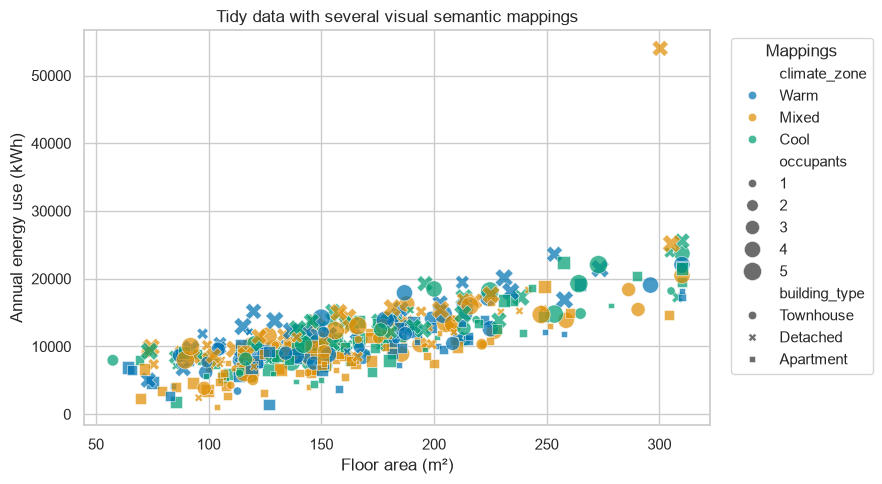

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=energy, x="floor_area_m2", y="annual_energy_kwh",
    hue="climate_zone", style="building_type", size="occupants",
    sizes=(35, 170), alpha=0.72, ax=ax,
)
ax.set(
    title="Tidy data with several visual semantic mappings",
    xlabel="Floor area (m²)", ylabel="Annual energy use (kWh)",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Mappings")
fig.tight_layout()
plt.show()

**Text alternative and limitation.** Larger buildings tend to appear higher on the energy-use axis; color, marker shape, and marker size distinguish climate zone, building type, and occupants. Several mappings make comparison efficient, but too many can overload a graphic. This one plot cannot tell which feature causes higher energy use, because features may be confounded.

## 2. EDA: distributions, missingness, and outliers

Before fitting a model, ask: What values are present? Which columns are missing? Are tails or outliers plausible measurements, data-entry errors, or distinct cases? A histogram answers a bin-dependent frequency question; an ECDF answers the cumulative proportion below each value without bin choices. Neither decides whether an outlier should be removed.

In [40]:
missing = energy.isna().sum().rename("missing_values").to_frame()
missing["percent"] = 100 * missing["missing_values"] / len(energy)
missing

,missing_values,percent
floor_area_m2,11,2.619048
insulation_score,32,7.619048
occupants,0,0.000000
building_type,0,0.000000
climate_zone,0,0.000000
annual_energy_kwh,0,0.000000


**Interpretation.** Missing `floor_area_m2` or `insulation_score` means a complete-case linear model will train on fewer observations. Missingness can also be systematic (for example, concentrated in one building type), so it is a modeling and fairness question—not merely a cleaning chore.

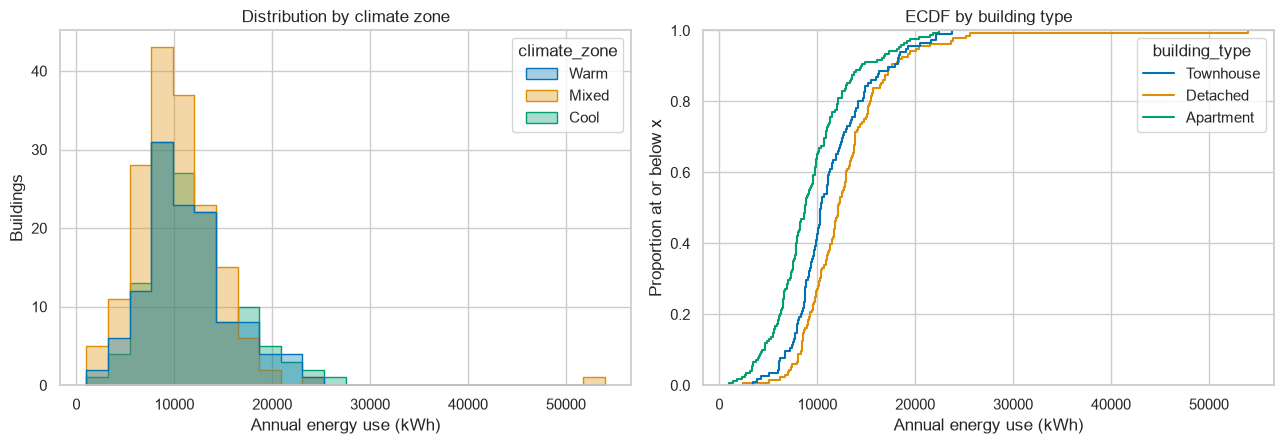

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.histplot(
    data=energy, x="annual_energy_kwh", hue="climate_zone",
    bins=24, multiple="layer", element="step", stat="count", common_norm=False,
    alpha=0.35, ax=axes[0],
)
axes[0].set(title="Distribution by climate zone", xlabel="Annual energy use (kWh)", ylabel="Buildings")

sns.ecdfplot(data=energy, x="annual_energy_kwh", hue="building_type", ax=axes[1])
axes[1].set(title="ECDF by building type", xlabel="Annual energy use (kWh)", ylabel="Proportion at or below x")
fig.tight_layout()
plt.show()

**Text alternative and limitation.** The histogram shows a long right tail, including a 54,000-kWh observation; the ECDF makes the cumulative position of high-use buildings visible without choosing bins. The high value is deliberately a recorded outlier in this synthetic example. In real work, inspect provenance and units before capping, deleting, or modeling it; a plot flags a question rather than supplying the answer.

## 3. Relationships, features, and targets

For a numeric feature and target, a scatter plot checks form, spread, and possible interactions. Transparency reduces overplotting; faceting asks whether a relationship looks different across a meaningful subgroup. Here the question is whether floor area and annual energy use look similarly related in each climate zone.

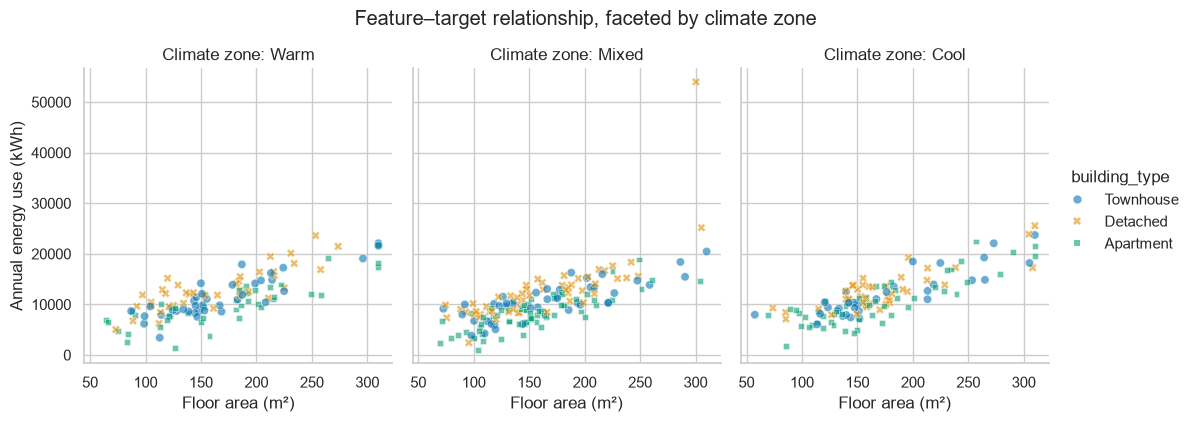

In [42]:
relationship = energy.dropna(subset=["floor_area_m2"]).copy()
g = sns.relplot(
    data=relationship, x="floor_area_m2", y="annual_energy_kwh",
    col="climate_zone", hue="building_type", style="building_type",
    kind="scatter", alpha=0.58, height=4, aspect=0.9,
)
g.set_axis_labels("Floor area (m²)", "Annual energy use (kWh)")
g.set_titles("Climate zone: {col_name}")
g.figure.suptitle("Feature–target relationship, faceted by climate zone", y=1.05)
plt.show()

**Text alternative and limitation.** Each facet shows a generally increasing cloud: larger floor area is associated with higher annual energy use within the simulated climate zones. Transparency reveals regions with many overlapping observations. The facets suggest that climate zone may matter, but this observational graphic does not establish a causal effect of area, climate, insulation, or building type. Modeling must still address confounding, validation, and the prediction task.

## 4. Categorical variables and honest group comparisons

Count plots answer “how much data supports each group?” Raw observations and distributions answer “how variable are the values?” A bare bar of group means can conceal sample size, skewness, and outliers, so show observations or a distribution alongside a summary whenever that context matters.

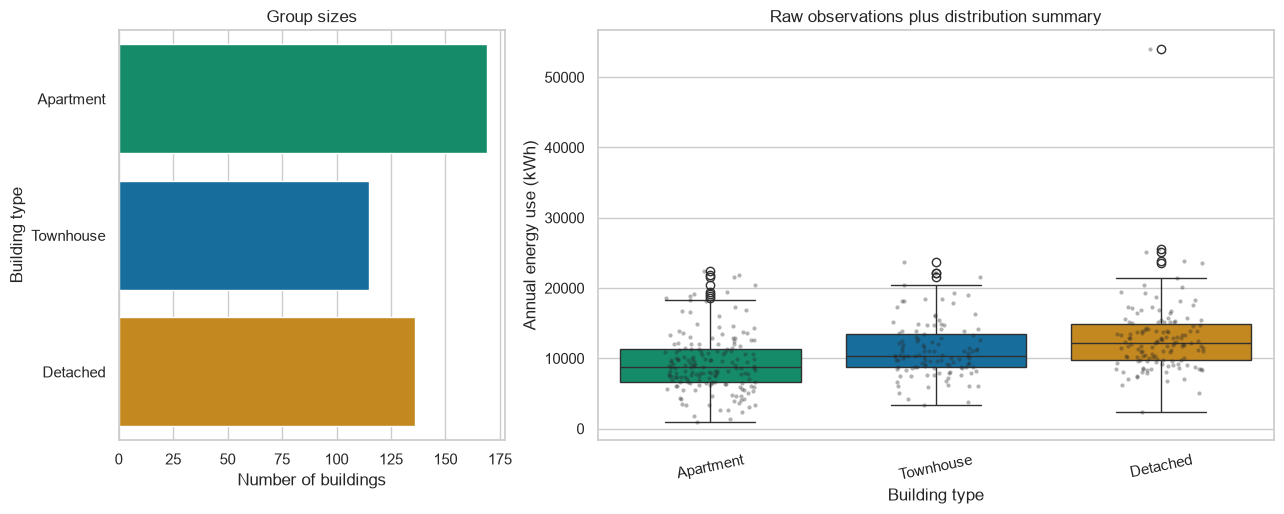

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), gridspec_kw={"width_ratios": [0.8, 1.4]})
order = ["Apartment", "Townhouse", "Detached"]
sns.countplot(data=energy, y="building_type", order=order, hue="building_type", legend=False, ax=axes[0])
axes[0].set(title="Group sizes", xlabel="Number of buildings", ylabel="Building type")

sns.boxplot(data=energy, x="building_type", y="annual_energy_kwh", order=order, hue="building_type", legend=False, ax=axes[1])
sns.stripplot(
    data=energy, x="building_type", y="annual_energy_kwh", order=order,
    color="0.15", alpha=0.35, jitter=0.2, size=3, ax=axes[1],
)
axes[1].set(title="Raw observations plus distribution summary", xlabel="Building type", ylabel="Annual energy use (kWh)")
axes[1].tick_params(axis="x", rotation=12)
fig.tight_layout()
plt.show()

**Text alternative and limitation.** The count panel displays the number of buildings in each category. The distribution panel overlays individual observations on box plots, revealing wide within-group variation and the high-use outlier. A mean-only bar chart would hide this shape and may make small or uneven groups appear more comparable than they are.

## 5. Uncertainty, regression visuals, and diagnostics

**Data spread** describes how individual observations vary. **Estimate uncertainty** describes how uncertain an estimated quantity, such as a group mean, is under a sampling procedure. In Seaborn 0.13+, use `errorbar=` rather than deprecated `ci=`. The next point plot uses a bootstrapped 95% confidence interval for each group mean; it is not a 95% interval containing individual buildings.

Regression graphics are exploratory visual guides. To make a prediction diagnostic, we actually fit a simple linear regression below, then plot its held-out actual values and residuals. This is still not a full ML evaluation: one would also set a validation design, compare models, and report metrics.

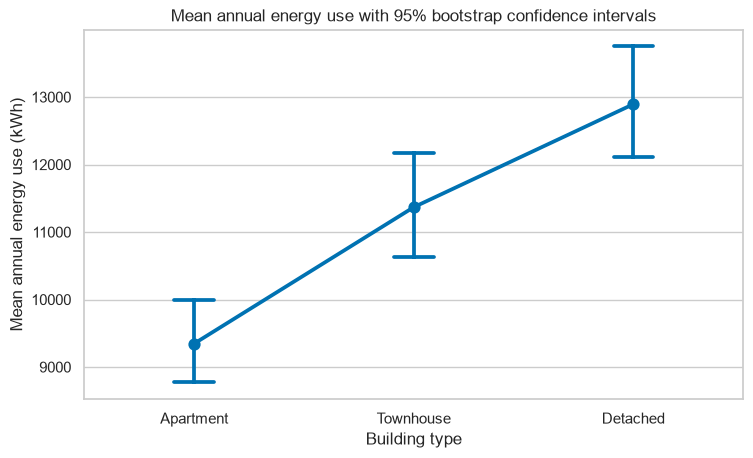

In [44]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.pointplot(
    data=energy, x="building_type", y="annual_energy_kwh", order=order,
    estimator="mean", errorbar=("ci", 95), capsize=0.18, color="#0072B2", ax=ax,
)
ax.set(
    title="Mean annual energy use with 95% bootstrap confidence intervals",
    xlabel="Building type", ylabel="Mean annual energy use (kWh)",
)
plt.show()

**Text alternative and limitation.** Each point is a group mean and its vertical error bar is a bootstrapped 95% confidence interval for that mean. These bars are much narrower than the raw-data spread in the earlier figure, because they answer a different question. Overlap or non-overlap alone is not a complete hypothesis test, and the synthetic groups are not a random sample from a population.

In [45]:
model_frame = energy.dropna(subset=["floor_area_m2", "insulation_score"]).copy()
features = pd.get_dummies(
    model_frame[["floor_area_m2", "insulation_score", "occupants", "building_type", "climate_zone"]],
    drop_first=True,
    dtype=float,
)
# A deterministic split makes the actual fitted prediction diagnostic reproducible.
test_mask = rng.random(len(model_frame)) < 0.25
model = LinearRegression().fit(features.loc[~test_mask], model_frame.loc[~test_mask, "annual_energy_kwh"])
model_frame["predicted_energy_kwh"] = model.predict(features)
model_frame["residual_kwh"] = model_frame["annual_energy_kwh"] - model_frame["predicted_energy_kwh"]
model_frame["split"] = np.where(test_mask, "Held-out", "Training")
held_out = model_frame.loc[test_mask].copy()
model_frame[["annual_energy_kwh", "predicted_energy_kwh", "residual_kwh", "split"]].head()

,annual_energy_kwh,predicted_energy_kwh,residual_kwh,split
0,17262.411258,16884.142932,378.268326,Training
1,9595.263312,10514.722669,-919.459357,Training
2,2681.864603,3672.195273,-990.330670,Training
3,15221.491014,13479.790522,1741.700492,Held-out
4,14603.156854,15650.309928,-1047.153074,Held-out


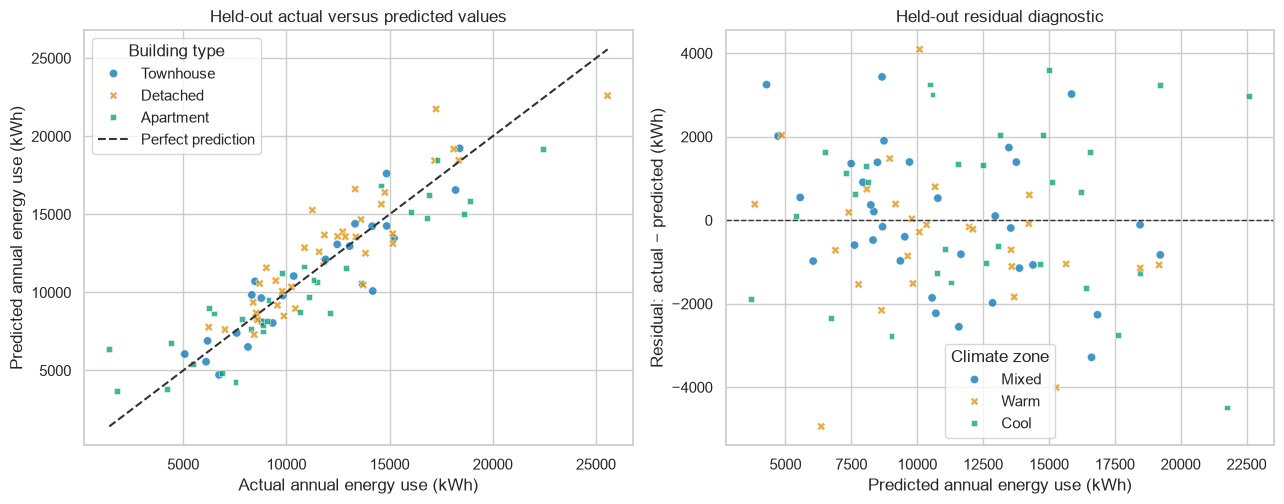

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
limits = [
    min(held_out["annual_energy_kwh"].min(), held_out["predicted_energy_kwh"].min()),
    max(held_out["annual_energy_kwh"].max(), held_out["predicted_energy_kwh"].max()),
]
sns.scatterplot(
    data=held_out, x="annual_energy_kwh", y="predicted_energy_kwh",
    hue="building_type", style="building_type", alpha=0.75, ax=axes[0],
)
axes[0].plot(limits, limits, color="0.2", linestyle="--", label="Perfect prediction")
axes[0].set(title="Held-out actual versus predicted values", xlabel="Actual annual energy use (kWh)", ylabel="Predicted annual energy use (kWh)")
axes[0].legend(title="Building type")

sns.scatterplot(
    data=held_out, x="predicted_energy_kwh", y="residual_kwh",
    hue="climate_zone", style="climate_zone", alpha=0.75, ax=axes[1],
)
axes[1].axhline(0, color="0.2", linestyle="--", linewidth=1)
axes[1].set(title="Held-out residual diagnostic", xlabel="Predicted annual energy use (kWh)", ylabel="Residual: actual − predicted (kWh)")
axes[1].legend(title="Climate zone")
fig.tight_layout()
plt.show()

**Text alternative and limitation.** In the left diagnostic, held-out points near the dashed diagonal have predictions close to actual values; the outlying high-use observation is likely far from it. In the right diagnostic, residuals should not show a strong systematic pattern if the simple model captures the main structure. Any patterns here motivate modeling questions, such as nonlinear terms or group interactions. They do not certify this model, quantify all performance, or replace formal validation.

## 6. Poster-ready figures: design, accessibility, and export

A poster figure should have a single stated question, readable labels with units, a descriptive caption, and a legend that does not carry meaning through color alone. Use a **qualitative** palette for unordered categories (such as building type), a **sequential** palette for ordered magnitude, and a **diverging** palette only when a meaningful midpoint exists. The colorblind palette used here is a good default for categories, but marker styles and direct prose make the comparison more robust.

`context="talk"` enlarges text for presentation-scale figures. Save vector graphics (`.svg` or `.pdf`) for editable print workflows and high-resolution raster graphics (`.png`, often 300 dpi or higher) when a raster file is required. The example below writes only to a temporary review directory, not the repository.

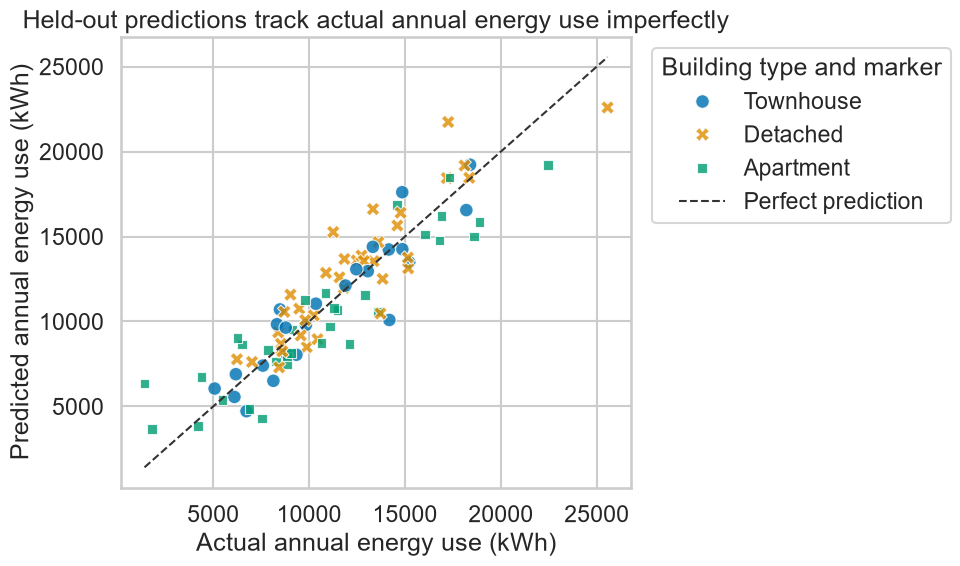

In [47]:
from pathlib import Path

sns.set_theme(context="talk", style="whitegrid", palette="colorblind")
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=held_out, x="annual_energy_kwh", y="predicted_energy_kwh",
    hue="building_type", style="building_type", s=95, alpha=0.82, ax=ax,
)
ax.plot(limits, limits, color="0.2", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set(
    title="Held-out predictions track actual annual energy use imperfectly",
    xlabel="Actual annual energy use (kWh)", ylabel="Predicted annual energy use (kWh)",
)
ax.legend(title="Building type and marker", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

review_dir = Path("/tmp/math6375-seaborn-review")
review_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(review_dir / "held-out-predictions.svg", bbox_inches="tight")
fig.savefig(review_dir / "held-out-predictions.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption / text alternative.** *Figure: Held-out annual-energy predictions from a simple linear regression fit on the synthetic building dataset. Points near the dashed equality line have smaller prediction error; color and marker shape both identify building type. The figure supports a diagnostic discussion, not a causal conclusion or a claim that the fitted model is production-ready.*

Before submitting a poster figure, inspect the exported file at its final physical size; check that labels and legends are readable, symbols are not distinguished by color alone, and the caption says what population, outcome, summary, and limitation are involved. For more options, consult Seaborn's [aesthetic tutorial](https://seaborn.pydata.org/tutorial/aesthetics.html), [color palette tutorial](https://seaborn.pydata.org/tutorial/color_palettes.html), and [`savefig` documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html).

## References

- Seaborn 0.13.2 documentation: [tutorial index](https://seaborn.pydata.org/tutorial.html) and [API reference](https://seaborn.pydata.org/api.html).
- Waskom, M. L. (2021). *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021

### Author AI-use disclosure
This notebook was drafted with AI assistance and reviewed by the course author; the examples, learning objective, and instructional framing remain subject to instructor review.